## 0. Load Data


*  mobility data (type='stop')
*  buildings (w. functional)
*  visitors (workers/residents/tourists)

In [1]:
import pandas as pd
import geopandas as gpd

geojson_path = '/content/drive/MyDrive/CUSP-GX 7103 7113 CAPSTONE/CAPSTONE WORK PROGRESS/Data/Sample_CanaryWharf/trail3_canary_wharf_buildings_classified.geojson'
buildings_gdf = gpd.read_file(geojson_path)

csv_path = '/content/drive/MyDrive/CUSP-GX 7103 7113 CAPSTONE/CAPSTONE WORK PROGRESS/Data/Sample_CanaryWharf/canarywharf_r10_2025-03_04.csv'
mbility_df = pd.read_csv(csv_path)
mbility_stops_df = mbility_df[mbility_df['type'] == 'stop']
mbility_stops_df.shape

(1876684, 7)

In [2]:
# Residents in CW
cw_residents_path = '/content/drive/MyDrive/CUSP-GX 7103 7113 CAPSTONE/CAPSTONE WORK PROGRESS/Data/Sample_CanaryWharf/user_ids_visitortype/cw_residents_user_ids.csv'
cw_residents_df = pd.read_csv(cw_residents_path)
# display(cw_residents_df.head())

cw_residents_ids = cw_residents_df['id'].unique()
mbility_stops_residents_df = mbility_stops_df[mbility_stops_df['id'].isin(cw_residents_ids)]
mbility_stops_residents_df.shape

(891605, 7)

In [3]:
# Workers in CW
workers_path = '/content/drive/MyDrive/CUSP-GX 7103 7113 CAPSTONE/CAPSTONE WORK PROGRESS/Data/Sample_CanaryWharf/user_ids_visitortype/likely_workers_ids.csv'
workers_df = pd.read_csv(workers_path)
# display(workers_df.head())

workers_ids = workers_df['user_id'].unique()
mbility_stops_workers_df = mbility_stops_df[mbility_stops_df['id'].isin(workers_ids)]
mbility_stops_workers_df.shape

(753881, 7)

In [4]:
# Tourists in CW
leisure_path = '/content/drive/MyDrive/CUSP-GX 7103 7113 CAPSTONE/CAPSTONE WORK PROGRESS/Data/Sample_CanaryWharf/user_ids_visitortype/leisure_user_ids.csv'
leisure_df = pd.read_csv(leisure_path)
# display(leisure_df.head())

leisure_ids = leisure_df['id'].unique()
mbility_stops_leisure_df = mbility_stops_df[mbility_stops_df['id'].isin(leisure_ids)]
mbility_stops_leisure_df.shape

(291945, 7)

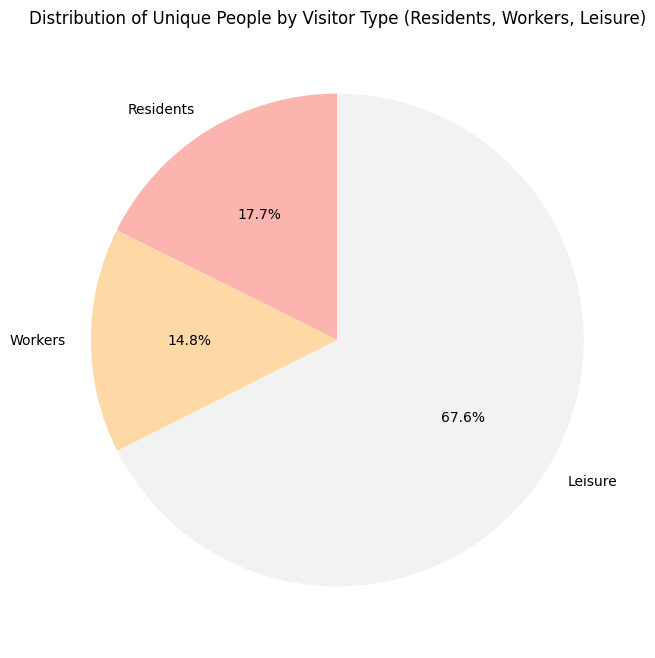

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# Data from the previous execution
unique_counts = {
    'mbility_stops_df': 157101,
    'mbility_stops_residents_df': 11903,
    'mbility_stops_workers_df': 9962,
    'mbility_stops_leisure_df': 45547
}

# Convert to pandas Series for easier plotting
distribution_series = pd.Series(unique_counts)

# For a pie chart, it's usually better to show the distribution *within* a subset, not the total.
# Let's focus on the distribution of Residents, Workers, and Leisure users relative to each other.
subset_counts = {
    'Residents': unique_counts['mbility_stops_residents_df'],
    'Workers': unique_counts['mbility_stops_workers_df'],
    'Leisure': unique_counts['mbility_stops_leisure_df']
}
subset_series = pd.Series(subset_counts)

plt.figure(figsize=(8, 8))
subset_series.plot.pie(autopct='%1.1f%%', startangle=90, cmap='Pastel1')
plt.title('Distribution of Unique People by Visitor Type (Residents, Workers, Leisure)')
plt.ylabel('') # Hide the default 'Series' label
plt.show()

In [5]:
print(f"Unique people in mbility_stops_df: {mbility_stops_df['id'].nunique()}")
print(f"Unique people in mbility_stops_residents_df: {mbility_stops_residents_df['id'].nunique()}")
print(f"Unique people in mbility_stops_workers_df: {mbility_stops_workers_df['id'].nunique()}")
print(f"Unique people in mbility_stops_leisure_df: {mbility_stops_leisure_df['id'].nunique()}")

Unique people in mbility_stops_df: 157101
Unique people in mbility_stops_residents_df: 11903
Unique people in mbility_stops_workers_df: 9962
Unique people in mbility_stops_leisure_df: 45547


## 1. Construct Dependency network by Visitors Layers

### 1.1 Construct Dependency Networks

In [ ]:
import pandas as pd
import geopandas as gpd
import networkx as nx
from shapely.geometry import Point

def build_dependency_network(mobility_df_type, buildings_gdf):
    # 1. Spatial mapping to buildings (with a 10m buffer)
    print("Step 1: Spatial mapping mobility data to buildings...")

    # Convert mobility_df_type to GeoDataFrame
    mobility_gdf = gpd.GeoDataFrame(
        mobility_df_type,
        geometry=gpd.points_from_xy(mobility_df_type.lon, mobility_df_type.lat),
        crs="EPSG:4326" # Assuming WGS84 for lat/lon
    )

    # Reproject buildings_gdf to a projected CRS for accurate buffering (e.g., British National Grid, EPSG:27700)
    buildings_proj = buildings_gdf.to_crs(epsg=27700)
    # Apply a 10m buffer
    buildings_buffered = buildings_proj.geometry.buffer(10)
    buildings_buffered_gdf = gpd.GeoDataFrame(buildings_proj[['id', 'building_name']], geometry=buildings_buffered, crs="EPSG:27700")

    # Reproject mobility data to the same CRS for spatial join
    mobility_gdf_proj = mobility_gdf.to_crs(epsg=27700)

    # Perform spatial join
    # We use 'sjoin_nearest' to find the closest building within the buffer distance.
    # This is more robust than just 'sjoin' for points possibly just outside.
    # For this task, a simple `sjoin` with `intersects` after buffering the buildings should work.
    mobility_with_buildings = gpd.sjoin(
        mobility_gdf_proj,
        buildings_buffered_gdf[['id', 'building_name', 'geometry']].rename(columns={'id': 'building_id', 'building_name': 'building_name_mapped'}),
        how="inner",
        predicate='intersects'
    )

    # Report map后的保留mobility数据比例
    retained_ratio = len(mobility_with_buildings) / len(mobility_df_type)
    print(f"  Retained mobility data after mapping to buildings: {retained_ratio:.2%}")

    # 2. Timestamp preprocessing and 3. Extract transition sequences
    print("Step 2 & 3: Preprocessing timestamps and extracting transition sequences...")

    # Sort by user ID and timestamp
    mobility_with_buildings = mobility_with_buildings.sort_values(by=['id', 'ts'])

    # Extract next building ID and next timestamp using shift
    mobility_with_buildings['next_building_id'] = mobility_with_buildings.groupby('id')['building_id'].shift(-1)
    mobility_with_buildings['next_ts'] = mobility_with_buildings.groupby('id')['ts'].shift(-1)

    # Filter out the last record for each user (where next_building_id is NaN)
    transitions_df = mobility_with_buildings.dropna(subset=['next_building_id']).copy()
    transitions_df['next_building_id'] = transitions_df['next_building_id'].astype(str) # Ensure consistent type

    # Calculate time difference in hours
    transitions_df['time_diff_hours'] = (transitions_df['next_ts'] - transitions_df['ts']) / 3600 # Convert seconds to hours

    # 3.5 过滤原地停留 (Self-loops) 与 极短时间抖动
    # 仅保留真正发生了建筑间位移的数据
    filtered_transitions = transitions_df[
        (transitions_df['building_id'] != transitions_df['next_building_id']) &
        (transitions_df['time_diff_hours'] > 0.016) # 比如过滤掉少于 1 分钟的转移
    ].copy()

    # 4. Filter and report
    print("Step 4: Filtering transitions and reporting...")

    # Filter for transitions within 24 hours
    valid_time_transitions = transitions_df[transitions_df['time_diff_hours'] <= 6]

    # Filter out buildings with less than 20 visits (as an origin building in transitions)
    building_visit_counts = valid_time_transitions['building_id'].value_counts()
    active_buildings = building_visit_counts[building_visit_counts >= 20].index

    filtered_transitions = valid_time_transitions[valid_time_transitions['building_id'].isin(active_buildings) & \
                                                  valid_time_transitions['next_building_id'].isin(active_buildings)]

    active_nodes_count = len(active_buildings)
    valid_cross_transitions_count = len(filtered_transitions)

    print(f"  Number of active buildings (nodes) with >= 20 origin visits: {active_nodes_count}")
    print(f"  Number of valid cross-building transitions (within 6h & active buildings): {valid_cross_transitions_count}")

    if filtered_transitions.empty:
        print("  No valid transitions to build a network.")
        return None

    # 5. Network construction
    print("Step 5: Constructing the dependency network...")

    # Calculate transition probabilities P(B|A)
    transition_counts = filtered_transitions.groupby(['building_id', 'next_building_id']).size().reset_index(name='count')
    origin_counts = filtered_transitions['building_id'].value_counts().reset_index(name='total_count')
    origin_counts.rename(columns={'index': 'building_id'}, inplace=True)

    transition_probs = pd.merge(transition_counts, origin_counts, on='building_id')
    transition_probs['probability'] = transition_probs['count'] / transition_probs['total_count']

    # Create a directed graph
    G = nx.DiGraph()

    # Add nodes (active buildings)
    for building_id in active_buildings:
        G.add_node(building_id)

    # Add edges with dependency strength as weight
    for _, row in transition_probs.iterrows():
        G.add_edge(row['building_id'], row['next_building_id'], weight=row['probability'], transitions=row['count'])

    # Calculate inflow and outflow for each node
    in_degree = dict(G.in_degree(weight='transitions')) # Use 'transitions' for raw count inflow
    out_degree = dict(G.out_degree(weight='transitions')) # Use 'transitions' for raw count outflow

    nx.set_node_attributes(G, in_degree, 'inflow')
    nx.set_node_attributes(G, out_degree, 'outflow')

    # Report network characteristics
    num_edges_strong_dependency = sum(1 for u, v, d in G.edges(data=True) if d['weight'] > 0.5) # Example threshold
    print(f"  Network created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")
    print(f"  Number of strong dependency paths (e.g., probability > 0.5): {num_edges_strong_dependency}")

    return G


(1) for Leisure Visitors

In [ ]:
print("Processing Leisure Visitors...")
leisure_dependency_network = build_dependency_network(mbility_stops_leisure_df, buildings_gdf)

if leisure_dependency_network:
    print("\nLeisure Dependency Network built successfully!")
    print(f"Nodes: {leisure_dependency_network.number_of_nodes()}")
    print(f"Edges: {leisure_dependency_network.number_of_edges()}")
    # Example: print top 5 nodes by inflow
    print("\nTop 5 buildings by total inflow (transition counts):")
    sorted_inflow = sorted(nx.get_node_attributes(leisure_dependency_network, 'inflow').items(), key=lambda item: item[1], reverse=True)
    for node, inflow in sorted_inflow[:5]:
        print(f"  Building ID: {node}, Inflow: {inflow}")
else:
    print("\nFailed to build Leisure Dependency Network.")

Processing Leisure Visitors...
Step 1: Spatial mapping mobility data to buildings...
  Retained mobility data after mapping to buildings: 5.63%
Step 2 & 3: Preprocessing timestamps and extracting transition sequences...
Step 4: Filtering transitions and reporting...
  Number of active buildings (nodes) with >= 20 origin visits: 85
  Number of valid cross-building transitions (within 6h & active buildings): 11621
Step 5: Constructing the dependency network...
  Network created with 85 nodes and 253 edges.
  Number of strong dependency paths (e.g., probability > 0.5): 80

Leisure Dependency Network built successfully!
Nodes: 85
Edges: 253

Top 5 buildings by total inflow (transition counts):
  Building ID: cc72c0ea-7504-42ec-8aec-33daafcd6451, Inflow: 655
  Building ID: db95edda-e33a-448e-975a-943d8f37c605, Inflow: 566
  Building ID: a663cae1-1883-4008-9cde-58bc752c388f, Inflow: 542
  Building ID: 82e2b683-2572-422c-8b59-e8824b5042fe, Inflow: 509
  Building ID: 12b707fc-a45c-4558-98fc-88

(2) for Residents

In [ ]:
print("Processing Residents...")
residents_dependency_network = build_dependency_network(mbility_stops_residents_df, buildings_gdf)

if residents_dependency_network:
    print("\nResidents Dependency Network built successfully!")
    print(f"Nodes: {residents_dependency_network.number_of_nodes()}")
    print(f"Edges: {residents_dependency_network.number_of_edges()}")
    print("\nTop 5 buildings by total inflow (transition counts):")
    sorted_inflow = sorted(nx.get_node_attributes(residents_dependency_network, 'inflow').items(), key=lambda item: item[1], reverse=True)
    for node, inflow in sorted_inflow[:5]:
        print(f"  Building ID: {node}, Inflow: {inflow}")
else:
    print("\nFailed to build Residents Dependency Network.")

Processing Residents...
Step 1: Spatial mapping mobility data to buildings...
  Retained mobility data after mapping to buildings: 11.50%
Step 2 & 3: Preprocessing timestamps and extracting transition sequences...
Step 4: Filtering transitions and reporting...
  Number of active buildings (nodes) with >= 20 origin visits: 106
  Number of valid cross-building transitions (within 6h & active buildings): 89177
Step 5: Constructing the dependency network...
  Network created with 106 nodes and 425 edges.
  Number of strong dependency paths (e.g., probability > 0.5): 99

Residents Dependency Network built successfully!
Nodes: 106
Edges: 425

Top 5 buildings by total inflow (transition counts):
  Building ID: db95edda-e33a-448e-975a-943d8f37c605, Inflow: 11735
  Building ID: dbd66115-c229-4ebc-b985-926c52169a31, Inflow: 5067
  Building ID: fe48f30d-5eb3-4ece-94f6-be71071b58ca, Inflow: 4413
  Building ID: cc72c0ea-7504-42ec-8aec-33daafcd6451, Inflow: 3826
  Building ID: e18d7e8a-1633-4c46-abd

(3) for Workers

In [ ]:
print("Processing Workers...")
workers_dependency_network = build_dependency_network(mbility_stops_workers_df, buildings_gdf)

if workers_dependency_network:
    print("\nWorkers Dependency Network built successfully!")
    print(f"Nodes: {workers_dependency_network.number_of_nodes()}")
    print(f"Edges: {workers_dependency_network.number_of_edges()}")
    print("\nTop 5 buildings by total inflow (transition counts):")
    sorted_inflow = sorted(nx.get_node_attributes(workers_dependency_network, 'inflow').items(), key=lambda item: item[1], reverse=True)
    for node, inflow in sorted_inflow[:5]:
        print(f"  Building ID: {node}, Inflow: {inflow}")
else:
    print("\nFailed to build Workers Dependency Network.")

Processing Workers...
Step 1: Spatial mapping mobility data to buildings...
  Retained mobility data after mapping to buildings: 21.28%
Step 2 & 3: Preprocessing timestamps and extracting transition sequences...
Step 4: Filtering transitions and reporting...
  Number of active buildings (nodes) with >= 20 origin visits: 110
  Number of valid cross-building transitions (within 6h & active buildings): 136965
Step 5: Constructing the dependency network...
  Network created with 110 nodes and 561 edges.
  Number of strong dependency paths (e.g., probability > 0.5): 99

Workers Dependency Network built successfully!
Nodes: 110
Edges: 561

Top 5 buildings by total inflow (transition counts):
  Building ID: db95edda-e33a-448e-975a-943d8f37c605, Inflow: 10655
  Building ID: cc72c0ea-7504-42ec-8aec-33daafcd6451, Inflow: 6225
  Building ID: 25c810fb-17d0-4331-9c9a-6cc5f5bb8042, Inflow: 6218
  Building ID: f9ed6834-375f-4fac-ae5c-d363ac9b931d, Inflow: 5323
  Building ID: e96252ed-33f8-446c-a5f0-d

In [ ]:
import pandas as pd
import geopandas as gpd
import networkx as nx
from shapely.geometry import Point

def build_dependency_network(mobility_df_type, buildings_gdf, time_window=4, min_visits=20):
    """
    构建基于建筑物的依赖网络
    time_window: 时间窗口（小时），建议根据 Elbow 测试设为  6
    min_visits: 活跃节点过滤阈值
    """
    print(f"Step 1: Spatial mapping mobility data to buildings...")

    # 1. 空间投影与连接
    mobility_gdf = gpd.GeoDataFrame(
        mobility_df_type,
        geometry=gpd.points_from_xy(mobility_df_type.lon, mobility_df_type.lat),
        crs="EPSG:4326"
    ).to_crs(epsg=27700) # 投影到英国国家坐标系计算距离

    buildings_proj = buildings_gdf.to_crs(epsg=27700)
    buildings_buffered_gdf = gpd.GeoDataFrame(
        buildings_proj[['id', 'building_name', 'final_functional_class']],
        geometry=buildings_proj.geometry.buffer(10),
        crs="EPSG:27700"
    )

    mobility_gdf_proj = mobility_gdf.to_crs(epsg=27700)

    # 执行空间连接并去重（防止一个点映射到多个邻近建筑）
    mapped_data = gpd.sjoin(
        mobility_gdf_proj,
        buildings_buffered_gdf.rename(columns={'id': 'building_id'}),
        how="inner",
        predicate='intersects'
    ).drop_duplicates(subset=['id', 'ts'])

    retained_ratio = len(mapped_data) / len(mobility_df_type)
    print(f"  Mapping retained mobility data: {retained_ratio:.2%}")

    # 2. 提取转移序列
    print("Step 2 & 3: Extracting cross-building transition sequences...")
    df = mapped_data.sort_values(by=['id', 'ts']).copy()

    df['next_building_id'] = df.groupby('id')['building_id'].shift(-1)
    df['next_ts'] = df.groupby('id')['ts'].shift(-1)
    df['time_diff_hours'] = (df['next_ts'] - df['ts']) / 3600

    # 核心过滤：
    # A. 必须有下一步记录
    # B. 必须在时间窗口内 (e.g., 4h or 6h)
    # C. 必须是跨建筑转移 (剔除 Self-loop: A -> A)
    # D. 过滤掉极短时间的噪声 ( < 1 分钟)
    valid_transitions = df[
        df['next_building_id'].notna() &
        (df['time_diff_hours'] <= time_window) &
        (df['building_id'] != df['next_building_id']) &
        (df['time_diff_hours'] > 0.016)
    ].copy()

    valid_transitions['next_building_id'] = valid_transitions['next_building_id'].astype(str)

    # 4. 活跃节点过滤 (Min Visits)
    print(f"Step 4: Filtering active nodes (min_visits >= {min_visits})...")
    counts = valid_transitions['building_id'].value_counts()
    active_buildings = counts[counts >= min_visits].index.tolist()

    # Filter transitions to ensure both origin and destination are part of the 'active' set.
    # This ensures that only transitions between buildings identified as 'active' (i.e., involved in at least one valid transition) are considered.
    final_transitions = valid_transitions[
        valid_transitions['building_id'].isin(active_buildings) &
        valid_transitions['next_building_id'].isin(active_buildings)
    ].copy()

    if final_transitions.empty:
        print("  No valid transitions found after filtering.")
        return None

    # 5. 构建网络指标
    print("Step 5: Constructing the dependency network...")

    # 计算转移概率 P(B|A)
    transition_counts = final_transitions.groupby(['building_id', 'next_building_id']).size().reset_index(name='count')
    origin_total = final_transitions['building_id'].value_counts().reset_index()
    origin_total.columns = ['building_id', 'total_outflow']

    # 合并数据
    probs = pd.merge(transition_counts, origin_total, on='building_id')

    # 使用正确的列名进行除法运算
    probs['probability'] = probs['count'] / probs['total_outflow']

    # 创建有向图
    G = nx.DiGraph()

    # 准备节点元数据映射
    # 确保 buildings_gdf 包含 'building_name' 和 'final_functional_class'
    meta_map = buildings_gdf.set_index('id')[['building_name', 'final_functional_class']].to_dict('index')

    # 添加活跃节点及其属性
    for b_id in active_buildings:
        info = meta_map.get(b_id, {'building_name': 'Unknown', 'final_functional_class': 'Other'})
        G.add_node(b_id,
                   name=info['building_name'],
                   category=info['final_functional_class'])

    # Add edges: only edges with probability > 0.01 are considered valid paths
    for _, row in probs.iterrows():
        if row['probability'] > 0.01:
            G.add_edge(row['building_id'], row['next_building_id'],
                       weight=row['probability'],
                       count=row['count'])

    # 注入出入流属性
    # 注意：这里使用 G.in_degree(weight='count') 得到的是该节点作为目的地的总转移数
    in_counts = dict(G.in_degree(weight='count'))
    out_counts = dict(G.out_degree(weight='count'))
    nx.set_node_attributes(G, in_counts, 'total_inflow')
    nx.set_node_attributes(G, out_counts, 'total_outflow')

    strong_links = sum(1 for u, v, d in G.edges(data=True) if d['weight'] > 0.5)
    print(f"  Network created: {G.number_of_nodes()} Nodes, {G.number_of_edges()} Edges. Strong dependencies (>0.5 probability): {strong_links}")

    return G

# ==========================================
# 调用示例
# ==========================================
# 假设我们统一使用 6h 窗口
print("Building Workers Network...")
G_workers = build_dependency_network(mbility_stops_workers_df, buildings_gdf, time_window=6, min_visits=20)

print("\nBuilding Residents Network...")
G_residents = build_dependency_network(mbility_stops_residents_df, buildings_gdf, time_window=6, min_visits=20)

print("\nBuilding Leisure Network...")
# 针对游客可以适当降低活跃度阈值
G_leisure = build_dependency_network(mbility_stops_leisure_df, buildings_gdf, time_window=4, min_visits=10)

Building Workers Network...
Step 1: Spatial mapping mobility data to buildings...
  Mapping retained mobility data: 18.93%
Step 2 & 3: Extracting cross-building transition sequences...
Step 4: Filtering active nodes (min_visits >= 20)...
Step 5: Constructing the dependency network...
  Network created: 61 Nodes, 241 Edges. Strong dependencies (>0.5 probability): 46

Building Residents Network...
Step 1: Spatial mapping mobility data to buildings...
  Mapping retained mobility data: 10.08%
Step 2 & 3: Extracting cross-building transition sequences...
Step 4: Filtering active nodes (min_visits >= 20)...
Step 5: Constructing the dependency network...
  Network created: 46 Nodes, 120 Edges. Strong dependencies (>0.5 probability): 36

Building Leisure Network...
Step 1: Spatial mapping mobility data to buildings...
  Mapping retained mobility data: 5.09%
Step 2 & 3: Extracting cross-building transition sequences...
Step 4: Filtering active nodes (min_visits >= 10)...
Step 5: Constructing th

### 1.3 Compare Network Metrics Across Visitor Types

,Visitor Type,Retained Data (%),Number of Nodes,Number of Edges
0,Leisure,5.63,85,253
1,Residents,11.50,106,425
2,Workers,21.28,110,561


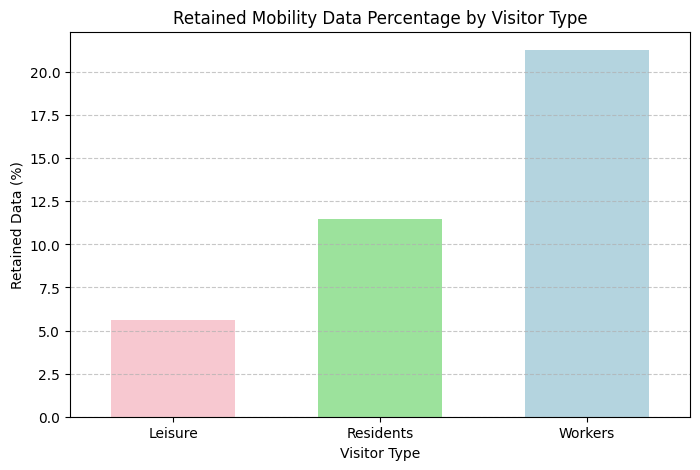

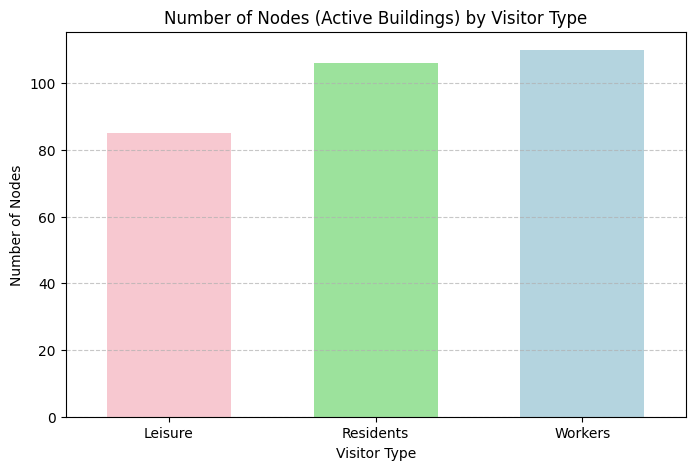

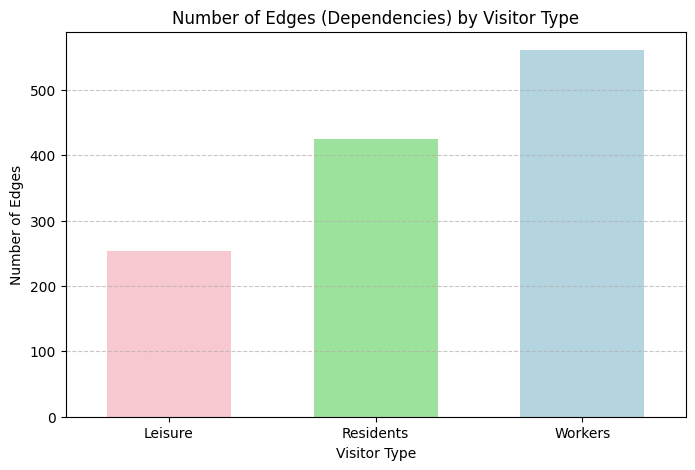

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data extracted from previous outputs
summary_data = {
    'Visitor Type': ['Leisure', 'Residents', 'Workers'],
    'Retained Data (%)': [5.63, 11.50, 21.28],
    'Number of Nodes': [85, 106, 110],
    'Number of Edges': [253, 425, 561]
}

summary_df = pd.DataFrame(summary_data)

display(summary_df)

# Custom color palette
custom_colors = {'Leisure': 'pink', 'Residents': 'lightgreen', 'Workers': 'lightblue'}

# Plotting functions
def plot_bar_comparison(df, y_col, title, ylabel, custom_palette, bar_width=0.6):
    plt.figure(figsize=(8, 5))
    # Assign 'Visitor Type' to hue and use the custom_palette as suggested by FutureWarning
    sns.barplot(x='Visitor Type', y=y_col, data=df, hue='Visitor Type', palette=custom_palette, legend=False, width=bar_width)
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel('Visitor Type')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# Create bar plots for each metric with custom colors and narrower bars
plot_bar_comparison(summary_df, 'Retained Data (%)', 'Retained Mobility Data Percentage by Visitor Type', 'Retained Data (%)', custom_colors, bar_width=0.6)
plot_bar_comparison(summary_df, 'Number of Nodes', 'Number of Nodes (Active Buildings) by Visitor Type', 'Number of Nodes', custom_colors, bar_width=0.6)
plot_bar_comparison(summary_df, 'Number of Edges', 'Number of Edges (Dependencies) by Visitor Type', 'Number of Edges', custom_colors, bar_width=0.6)


### 1.2 Calculate Features

Mapping groups to spatial buildings...
Mapping 753881 points to buildings...
Mapping complete. Retained: 18.93%
Mapping 891605 points to buildings...
Mapping complete. Retained: 10.08%
Mapping 291945 points to buildings...
Mapping complete. Retained: 5.09%

--- Workers Sensitivity Table ---
Window(h)  | Transitions  | Edges    | Strong_Paths
24         | 6751         | 572      | 70          
12         | 6056         | 491      | 73          
8          | 5818         | 465      | 72          
6          | 5608         | 445      | 73          
4          | 5176         | 382      | 75          
3          | 4785         | 350      | 75          
2          | 4107         | 298      | 77          
1          | 2817         | 191      | 68          
0.5        | 1679         | 116      | 56          


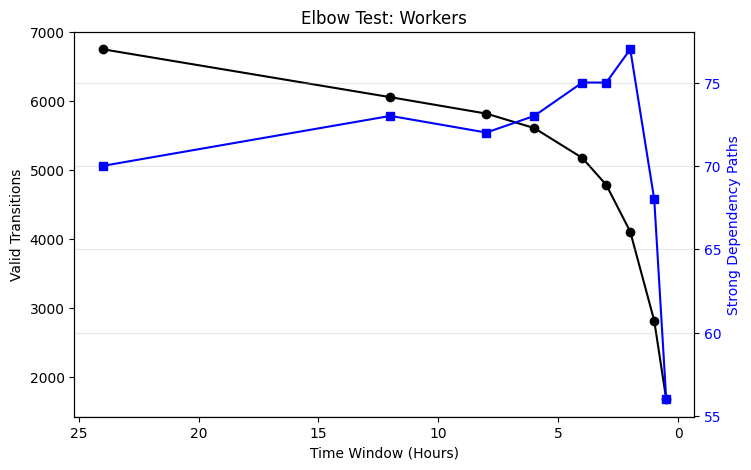


--- Residents Sensitivity Table ---
Window(h)  | Transitions  | Edges    | Strong_Paths
24         | 5005         | 377      | 64          
12         | 4553         | 334      | 61          
8          | 4288         | 308      | 64          
6          | 4068         | 283      | 63          
4          | 3688         | 225      | 60          
3          | 3398         | 204      | 60          
2          | 2934         | 171      | 61          
1          | 2074         | 127      | 55          
0.5        | 1251         | 84       | 42          


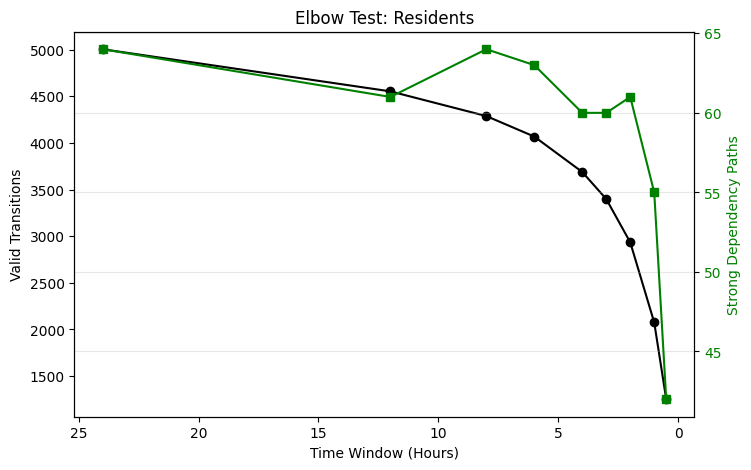


--- Leisure Sensitivity Table ---
Window(h)  | Transitions  | Edges    | Strong_Paths
24         | 414          | 96       | 35          
12         | 388          | 86       | 36          
8          | 379          | 83       | 37          
6          | 373          | 82       | 36          
4          | 330          | 70       | 35          
3          | 288          | 58       | 32          
2          | 237          | 46       | 28          
1          | 127          | 27       | 19          
0.5        | 67           | 17       | 12          


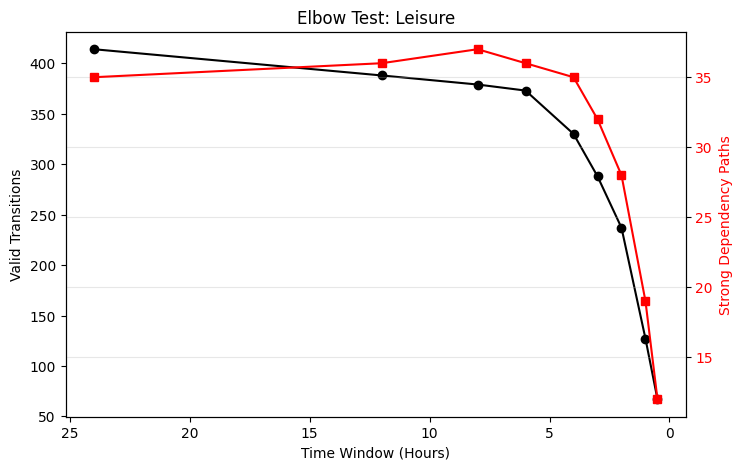

In [ ]:
import pandas as pd
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt

# ==========================================
# 1. 空间映射工具 (Spatial Mapping)
# ==========================================
def map_mobility_to_buildings(mobility_df, buildings_gdf, buffer_meters=10):
    """将轨迹点映射到建筑Polygon，并返回带有 building_id 的 DataFrame"""
    print(f"Mapping {len(mobility_df)} points to buildings...")

    # 转换为 GeoDataFrame
    mobility_gdf = gpd.GeoDataFrame(
        mobility_df,
        geometry=gpd.points_from_xy(mobility_df.lon, mobility_df.lat),
        crs="EPSG:4326"
    ).to_crs(epsg=27700) # 投影到英国国家坐标系计算距离

    # 建筑数据投影并做 Buffer
    buildings_proj = buildings_gdf.to_crs(epsg=27700)
    buildings_buffered = buildings_proj.copy()
    buildings_buffered['geometry'] = buildings_proj.geometry.buffer(buffer_meters)

    # 空间连接: 只要点在建筑10米范围内就挂载
    mapped = gpd.sjoin(
        mobility_gdf,
        buildings_buffered[['id', 'building_name', 'geometry']].rename(columns={'id': 'building_id'}),
        how="inner",
        predicate='intersects'
    )

    # 防止一个点映射到多个邻近建筑，按最近距离去重或简单去重
    mapped = mapped.drop_duplicates(subset=['id', 'ts'])

    print(f"Mapping complete. Retained: {len(mapped)/len(mobility_df):.2%}")
    return pd.DataFrame(mapped.drop(columns='geometry')) # 转回DF方便后续处理

# ==========================================
# 2. Elbow 测试函数 (Sensitivity Analysis)
# ==========================================
def run_elbow_analysis(mapped_df, group_name, windows=[24, 12, 8, 6, 4, 3, 2, 1, 0.5], transition_color='black', strong_path_color='red'):
    """测试不同窗口下的转移特征"""
    results = []

    # 预排序
    df = mapped_df.sort_values(['id', 'ts']).copy()

    # 提取下一步信息
    df['next_building_id'] = df.groupby('id')['building_id'].shift(-1)
    df['next_ts'] = df.groupby('id')['ts'].shift(-1)
    df['time_diff_hours'] = (df['next_ts'] - df['ts']) / 3600

    # 基础过滤：必须有下一步，且不是原地停留
    base_transitions = df.dropna(subset=['next_building_id']).copy()
    base_transitions = base_transitions[base_transitions['building_id'] != base_transitions['next_building_id']]

    print(f"\n--- {group_name} Sensitivity Table ---")
    print(f"{'Window(h)':<10} | {'Transitions':<12} | {'Edges':<8} | {'Strong_Paths':<12}")

    for w in windows:
        # 按当前窗口过滤时间
        current = base_transitions[base_transitions['time_diff_hours'] <= w].copy()

        # 统计活跃节点 (访问>=20次)
        counts = current['building_id'].value_counts()
        active_nodes = counts[counts >= 5].index

        final = current[current['building_id'].isin(active_nodes) &
                        current['next_building_id'].isin(active_nodes)]

        if final.empty: continue

        # 计算边和权重
        edge_data = final.groupby(['building_id', 'next_building_id']).size().reset_index(name='cnt')
        total_out = final['building_id'].value_counts().to_dict()
        edge_data['prob'] = edge_data['cnt'] / edge_data['building_id'].map(total_out)

        # 指标记录
        res = {
            'window': w,
            'transitions': len(final),
            'edges': len(edge_data),
            'strong_paths': len(edge_data[edge_data['prob'] > 0.5])
        }
        results.append(res)
        print(f"{w:<10} | {res['transitions']:<12} | {res['edges']:<8} | {res['strong_paths']:<12}")

    # 绘图逻辑
    res_df = pd.DataFrame(results)
    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax1.plot(res_df['window'], res_df['transitions'], 'o-', color=transition_color, label='Transitions')
    ax1.set_xlabel('Time Window (Hours)')
    ax1.set_ylabel('Valid Transitions', color=transition_color)
    ax1.tick_params(axis='y', labelcolor=transition_color)
    ax1.invert_xaxis()

    ax2 = ax1.twinx()
    ax2.plot(res_df['window'], res_df['strong_paths'], 's-', color=strong_path_color, label='Strong Paths (>0.5)')
    ax2.set_ylabel('Strong Dependency Paths', color=strong_path_color)
    ax2.tick_params(axis='y', labelcolor=strong_path_color)

    plt.title(f'Elbow Test: {group_name}')
    plt.grid(True, alpha=0.3)
    plt.show()
    return res_df

# ==========================================
# 3. 完整执行流程
# ==========================================

# 第一步：先做空间映射 (这一步最耗时，每个群体只跑一次)
print("Mapping groups to spatial buildings...")
mapped_workers = map_mobility_to_buildings(mbility_stops_workers_df, buildings_gdf)
mapped_residents = map_mobility_to_buildings(mbility_stops_residents_df, buildings_gdf)
mapped_leisure = map_mobility_to_buildings(mbility_stops_leisure_df, buildings_gdf)

# 定义颜色映射
color_map = {
    "Leisure": "red",
    "Residents": "green",
    "Workers": "blue"
}

# 第二步：跑 Elbow 测试
all_results = {}
for name, data in [("Workers", mapped_workers), ("Residents", mapped_residents), ("Leisure", mapped_leisure)]:
    strong_path_color = color_map.get(name, 'red') # Default to red if not found
    all_results[name] = run_elbow_analysis(data, name, transition_color='black', strong_path_color=strong_path_color)


In [ ]:
def analyze_transition_types(mapped_df, group_name, time_window=4):
    """
    计算 Self-loop 和 Cross-building 转移的比例
    mapped_df: 已经完成空间映射的 DataFrame
    group_name: 群体名称
    time_window: 时间窗口(小时)，建议使用我们 Elbow 测试得出的 6h
    """
    # 1. 预处理
    df = mapped_df.sort_values(['id', 'ts']).copy()

    # 2. 提取序列信息
    df['next_building_id'] = df.groupby('id')['building_id'].shift(-1)
    df['next_ts'] = df.groupby('id')['ts'].shift(-1)
    df['time_diff_hours'] = (df['next_ts'] - df['ts']) / 3600

    # 3. 过滤出有效转移（在时间窗口内，且有下一步记录）
    valid_transitions = df.dropna(subset=['next_building_id']).copy()
    valid_transitions = valid_transitions[valid_transitions['time_diff_hours'] <= time_window]

    total_valid = len(valid_transitions)

    if total_valid == 0:
        print(f"No valid transitions found for {group_name} within {time_window}h.")
        return None

    # 4. 判定类型
    # Self-loop: A -> A
    # Cross-building: A -> B
    self_loops = valid_transitions[valid_transitions['building_id'] == valid_transitions['next_building_id']]
    cross_buildings = valid_transitions[valid_transitions['building_id'] != valid_transitions['next_building_id']]

    count_self = len(self_loops)
    count_cross = len(cross_buildings)

    # 5. 计算比例
    ratio_self = (count_self / total_valid) * 100
    ratio_cross = (count_cross / total_valid) * 100

    # 6. 报告结果
    print(f"\n" + "="*40)
    print(f"TRANSITION TYPE REPORT: {group_name}")
    print(f"Time Window: {time_window} hours")
    print(f"-"*40)
    print(f"Total Valid Transitions: {total_valid}")
    print(f"Self-Loops (A -> A):     {count_self:<8} ({ratio_self:.2f}%)")
    print(f"Cross-Buildings (A -> B): {count_cross:<8} ({ratio_cross:.2f}%)")
    print(f"Self-to-Cross Ratio:      {count_self/count_cross:.2f}" if count_cross > 0 else "N/A")
    print(f"="*40)

    return {
        'group': group_name,
        'self_loop_pct': ratio_self,
        'cross_building_pct': ratio_cross,
        'total': total_valid
    }

# 2. 分别调用不同群体
# 使用我们之前得到的映射后的数据
results = []
results.append(analyze_transition_types(mapped_workers, "Workers", time_window=4))
results.append(analyze_transition_types(mapped_residents, "Residents", time_window=4))
results.append(analyze_transition_types(mapped_leisure, "Leisure", time_window=4))


TRANSITION TYPE REPORT: Workers
Time Window: 4 hours
----------------------------------------
Total Valid Transitions: 117183
Self-Loops (A -> A):     111891   (95.48%)
Cross-Buildings (A -> B): 5292     (4.52%)
Self-to-Cross Ratio:      21.14

TRANSITION TYPE REPORT: Residents
Time Window: 4 hours
----------------------------------------
Total Valid Transitions: 75205
Self-Loops (A -> A):     71320    (94.83%)
Cross-Buildings (A -> B): 3885     (5.17%)
Self-to-Cross Ratio:      18.36

TRANSITION TYPE REPORT: Leisure
Time Window: 4 hours
----------------------------------------
Total Valid Transitions: 10389
Self-Loops (A -> A):     9871     (95.01%)
Cross-Buildings (A -> B): 518      (4.99%)
Self-to-Cross Ratio:      19.06


In [ ]:
import numpy as np

def calculate_network_cv(G, group_name):
    """
    计算网络节点 Inflow 的变异系数 (CV)
    """
    # 提取所有节点的流入量 (total_inflow)
    inflows = [d.get('total_inflow', 0) for n, d in G.nodes(data=True)]

    if not inflows:
        return None

    mean_inflow = np.mean(inflows)
    std_inflow = np.std(inflows)

    # 计算 CV
    cv = std_inflow / mean_inflow if mean_inflow > 0 else 0

    print(f"[{group_name}] Inflow Statistics:")
    print(f"  Mean: {mean_inflow:.2f}")
    print(f"  Std Dev: {std_inflow:.2f}")
    print(f"  CV (Coefficient of Variation): {cv:.4f}")

    return cv

# 分别计算三个群体
cv_workers = calculate_network_cv(G_workers, "Workers")
cv_residents = calculate_network_cv(G_residents, "Residents")
cv_leisure = calculate_network_cv(G_leisure, "Leisure")

[Workers] Inflow Statistics:
  Mean: 80.64
  Std Dev: 80.18
  CV (Coefficient of Variation): 0.9943
[Residents] Inflow Statistics:
  Mean: 75.28
  Std Dev: 89.48
  CV (Coefficient of Variation): 1.1886
[Leisure] Inflow Statistics:
  Mean: 10.71
  Std Dev: 4.31
  CV (Coefficient of Variation): 0.4024


## 3. Visualization

### 3.1 Dependency Network for workers

In [ ]:
import folium
from folium import plugins
import numpy as np

def visualize_dependency_map(G, buildings_gdf, group_name="Group"):
    """
    使用 Folium 绘制交互式依赖网络地图
    """
    if G is None or G.number_of_nodes() == 0:
        print(f"Warning: No data to plot for {group_name}")
        return None

    # 1. 准备地理数据：确保是 WGS84 坐标系用于 Folium
    buildings_4326 = buildings_gdf.to_crs(epsg=4326).set_index('id')

    # 获取地图中心点
    avg_lat = buildings_4326.geometry.centroid.y.mean()
    avg_lon = buildings_4326.geometry.centroid.x.mean()

    m = folium.Map(location=[avg_lat, avg_lon], zoom_start=15, tiles='cartodbpositron')

    # 添加标题
    title_html = f'''<h3 align="center" style="font-size:16px"><b>Dependency Network: {group_name}</b></h3>'''
    m.get_root().html.add_child(folium.Element(title_html))

    # 2. 绘制建筑 Polygon
    # 只绘制存在于网络中的节点建筑
    active_node_ids = list(G.nodes())
    existing_active_buildings = buildings_4326[buildings_4326.index.isin(active_node_ids)]

    for b_id, row in existing_active_buildings.iterrows():
        # 获取该节点的流入流出信息
        inflow = G.nodes[b_id].get('total_inflow', 0)
        category = G.nodes[b_id].get('category', 'N/A')

        sim_geo = folium.GeoJson(
            row.geometry,
            style_function=lambda x: {
                'fillColor': '#3186cc',
                'color': 'black',
                'weight': 1,
                'fillOpacity': 0.4
            },
            tooltip=f"Name: {G.nodes[b_id].get('name')}<br>Type: {category}<br>Inflow: {inflow}"
        )
        sim_geo.add_to(m)

    # 3. 绘制依赖关系边 (Edges)
    # 计算所有权重的最大值用于归一化线宽
    max_weight = max([d['weight'] for u, v, d in G.edges(data=True)]) if G.edges else 1

    for u, v, d in G.edges(data=True):
        try:
            # 获取起点和终点的中心点坐标
            p1 = buildings_4326.loc[u].geometry.centroid
            p2 = buildings_4326.loc[v].geometry.centroid

            # 根据权重设置颜色和线宽
            # 权重越高，颜色越红，线越粗
            weight = d['weight']
            normalized_weight = weight / max_weight

            color = "#FF4500" if weight > 0.5 else "#3186cc" # 强依赖用橙红色
            opacity = 0.2 + (0.6 * normalized_weight)
            line_weight = 1 + (5 * normalized_weight)

            points = [[p1.y, p1.x], [p2.y, p2.x]]

            folium.PolyLine(
                points,
                color=color,
                weight=line_weight,
                opacity=opacity,
                tooltip=f"From: {G.nodes[u].get('name')}<br>To: {G.nodes[v].get('name')}<br>Prob: {weight:.2f}"
            ).add_to(m)

            # 添加一个小箭头/终点标记（可选）
            if weight > 0.3: # 只给中高强度的连接加标记，防止地图太乱
                folium.CircleMarker(
                    location=[p2.y, p2.x],
                    radius=2,
                    color='red',
                    fill=True
                ).add_to(m)

        except KeyError:
            continue

    return m

In [ ]:
# 1. 绘制 Workers 地图
print("Generating Workers Map...")
map_workers = visualize_dependency_map(G_workers, buildings_gdf, "Workers")
# map_workers.save("map_workers.html") # 如果需要保存到本地
map_workers # 在 Jupyter 中直接显示

Generating Workers Map...


/tmp/ipykernel_1835/1664322451.py:17: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  avg_lat = buildings_4326.geometry.centroid.y.mean()
/tmp/ipykernel_1835/1664322451.py:18: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  avg_lon = buildings_4326.geometry.centroid.x.mean()


In [ ]:
import folium
from folium import plugins
import pandas as pd
import geopandas as gpd
import numpy as np

def visualize_functional_dependency_map(G, buildings_gdf, group_name="Workers"):
    """
    修正版：彻底解决 Building Name 为 '0' 的问题，并优化了 POI 回退显示。
    """
    # 1. 坐标转换
    nodes_4326 = buildings_gdf.to_crs(epsg=4326).set_index('id')

    # 定义功能颜色映射
    color_map = {
        'Other': '#808080', 'Small Retail/Dining': '#FFA500',
        'Shopping Mall': '#FF0000', 'Mixed-use/Complex': '#FFFF00',
        'Residential': '#008000', 'Education': '#800080',
        'Transit Hub': '#00FFFF', 'Office/HQ': '#007bff',
    }

    m = folium.Map(location=[51.5048, -0.0210], zoom_start=16, tiles='CartoDB positron')

    # 计算节点吞吐量及全局范围
    node_stats = {}
    for node_id in G.nodes():
        inf = G.nodes[node_id].get('total_inflow', 0)
        outf = G.nodes[node_id].get('total_outflow', 0)
        node_stats[str(node_id)] = {'in': inf, 'out': outf, 'total': inf + outf}

    all_totals = [s['total'] for s in node_stats.values()]
    max_tp = max(all_totals) if all_totals else 1
    min_tp = min(all_totals) if all_totals else 0

    # 2. 绘制建筑 Polygon
    for b_id, row in nodes_4326.iterrows():
        b_id_str = str(b_id)

        # --- 核心修正：多重过滤逻辑处理 Building Name ---
        raw_name = str(row.get('building_name', '')).strip()
        poi_raw = str(row.get('all_poi_names', '')).strip()
        poi_list = [p.strip() for p in poi_raw.split(',')] if poi_raw and poi_raw.lower() != 'nan' else []

        # 判断名字是否无效 (增加对 '0' 和 '0.0' 的判断)
        invalid_names = ['', 'nan', 'unknown', 'none', '0', '0.0']
        if raw_name.lower() in invalid_names:
            # 尝试回退到 POI，但要排除 "No POIs recorded"
            if poi_list and poi_list[0].lower() != "no pois recorded":
                display_name = f"{poi_list[0]} (POI)"
            else:
                display_name = f"Building {b_id_str[:8]}..." # 使用短 ID
        else:
            display_name = raw_name

        # 同步更新 G 节点中的名字，以便连线 Tooltip 显示正确
        if b_id_str in G.nodes:
            G.nodes[b_id_str]['name'] = display_name

        # 透明度计算
        stats = node_stats.get(b_id_str, {'in': 0, 'out': 0, 'total': 0})
        if max_tp > min_tp:
            norm_val = (stats['total'] - min_tp) / (max_tp - min_tp)
            node_opacity = 0.2 + (0.65 * norm_val)
        else:
            node_opacity = 0.4

        fill_color = color_map.get(row['final_functional_class'], "#95a5a6")

        # 插入 POI Num (poi_sum) 并构造内容
        raw_ratio = row.get('Retail_Food_Ratio', np.nan)
        ratio_disp = "N/A" if pd.isna(raw_ratio) else f"{raw_ratio:.1f}%"
        poi_num = int(float(row.get('poi_sum', 0))) # 确保浮点字符串也能转 int

        poi_items_html = "".join([f"<li style='margin-bottom:2px;'>{p}</li>" for p in poi_list]) if poi_list else "<li>No POIs listed</li>"

        # 构造信息框内容 (使用 popup_content)
        popup_content = f"""
        <div style="width:260px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
            <h4 style="margin:0 0 8px 0; color:#333; border-bottom:2px solid {fill_color}; padding-bottom:3px;">{display_name}</h4>
            <div style="font-size:13px; line-height:1.6;">
                <b>Functional Class:</b> {row['final_functional_class']}<br>
                <b>Throughput:</b> <span style="color:#2c3e50; font-weight:bold;">{stats['total']}</span> (In:{stats['in']}, Out:{stats['out']})<br>
                <b>POI Num:</b> {poi_num}<br>
                <b>Retail/Food Ratio:</b> {ratio_disp}
            </div>
            <details style="margin-top:10px; font-size:12px; border:1px solid #eee; border-radius:4px; padding:5px; background-color:#f9f9f9;">
                <summary style="cursor:pointer; color:#007bff; font-weight:bold;">Click to view all {poi_num} POIs</summary>
                <ul style="margin:5px 0 0 0; padding-left:18px; max-height:150px; overflow-y:auto; color:#555;">
                    {poi_items_html}
                </ul>
            </details>
        </div>
        """

        folium.GeoJson(
            row['geometry'],
            style_function=lambda x, fc=fill_color, fo=node_opacity: {
                'fillColor': fc, 'color': '#2c3e50', 'weight': 1, 'fillOpacity': fo
            },
            tooltip=f"<b>{display_name}</b><br>Throughput: {stats['total']}",
            popup=folium.Popup(popup_content, max_width=300)
        ).add_to(m)

    # 3. 叠加金色连线
    edge_layer = folium.FeatureGroup(name=f"{group_name} Network Transitions")
    all_weights = [d['weight'] for u, v, d in G.edges(data=True)]
    max_w = max(all_weights) if all_weights else 1

    for u, v, d in G.edges(data=True):
        try:
            u_s, v_s = str(u), str(v)
            p1 = nodes_4326.loc[u_s].geometry.centroid
            p2 = nodes_4326.loc[v_s].geometry.centroid
            prob = d['weight']
            line_weight = 1 + (prob / max_w * 7)

            name_u = G.nodes[u_s].get('name', u_s)
            name_v = G.nodes[v_s].get('name', v_s)

            if prob > 0.01:
                folium.PolyLine(
                    locations=[[p1.y, p1.x], [p2.y, p2.x]],
                    color="#FFD700", weight=line_weight, opacity=0.6,
                    tooltip=f"<b>Direction:</b> {name_u} &rarr; {name_v}<br><b>Prob:</b> {prob:.2%}"
                ).add_to(edge_layer)

                if prob > 0.1:
                    folium.CircleMarker(location=[p2.y, p2.x], radius=2, color='#FFD700', fill=True, fill_opacity=0.8).add_to(edge_layer)
        except Exception:
            continue

    edge_layer.add_to(m)

    # 4. 图例
    legend_html = f'''
    <div style="position: fixed; bottom: 40px; left: 40px; width: 240px; z-index:9999;
    background: white; padding: 12px; border: 2px solid grey; border-radius: 6px; font-family: Arial; font-size: 12px;">
        <b style="font-size:13px;">{group_name} Network Analysis</b><br>
        <div style="margin-top:8px; line-height:1.7;">
            <span style="color:#FFD700; font-size:18px;">━</span> <b>Dependency</b> (Thickness \u221D Prob)<br>
            <span style="color:#2c3e50; font-size:18px;">\u25A0</span> <b>Opacity</b> \u221D Throughput<br>
            <hr style="margin:8px 0; border-top:1px solid #ddd;">
            <span style="color:#007bff;">\u25A0</span> Office/HQ &nbsp; <span style="color:#FF0000;">\u25A0</span> Shopping Mall<br>
            <span style="color:#FFFF00;">\u25A0</span> Mixed-use &nbsp; <span style="color:#FFA500;">\u25A0</span> Small Retail<br>
            <span style="color:#008000;">\u25A0</span> Residential &nbsp; <span style="color:#800080;">\u25A0</span> Education<br>
            <span style="color:#00FFFF;">\u25A0</span> Transit Hub &nbsp; <span style="color:#808080;">\u25A0</span> Other
        </div>
    </div>
    '''
    m.get_root().html.add_child(folium.Element(legend_html))
    folium.LayerControl().add_to(m)
    return m

# --- 执行并保存 ---
print("🚀 Finalizing map with robust '0' name handling...")
map_final = visualize_functional_dependency_map(G_workers, buildings_gdf, "Workers")
map_final.save("Canary_Wharf_Network_Final_V3.html")
print("✅ Done! Map saved as 'Canary_Wharf_Network_Final_V3.html'")

🚀 Finalizing map with robust '0' name handling...
✅ Done! Map saved as 'Canary_Wharf_Network_Final_V3.html'


In [ ]:
map_final

### 3.2 Temporally Visitations

In [ ]:
import pandas as pd
import geopandas as gpd
from datetime import datetime

def prepare_cyclical_visitations(stops_dict, buildings_gdf):
    """
    将两个月的数据聚合为 24 小时循环数据
    stops_dict: {'Worker': df1, 'Resident': df2, 'Leisure': df3}
    """
    all_processed = []

    # 预处理建筑中心点
    buildings_proj = buildings_gdf.to_crs(epsg=27700)
    centroids = buildings_proj.copy()
    centroids['geometry'] = centroids.geometry.centroid
    centroids = centroids.to_crs(epsg=4326)
    centroids['lon'] = centroids.geometry.x
    centroids['lat'] = centroids.geometry.y
    centroid_map = centroids[['id', 'lat', 'lon', 'building_name', 'final_functional_class']].set_index('id').to_dict('index')

    for group_label, df in stops_dict.items():
        # 1. 空间连接映射到建筑 (复用之前的逻辑)
        gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.lon, df.lat), crs="EPSG:4326").to_crs(epsg=27700)
        joined = gpd.sjoin(gdf, buildings_proj[['id', 'geometry']], how="inner", predicate="intersects")

        # 2. 转换时间为 24 小时周期
        # 假设 ts 是 unix timestamp
        dt_series = pd.to_datetime(joined['ts'], unit='s')

        # 构造虚拟日期：2025-01-01 HH:MM:SS
        joined['cycle_timestamp'] = dt_series.apply(
            lambda x: datetime(2025, 1, 1, x.hour, x.minute, x.second)
        )

        # 3. 提取中心点坐标
        def get_info(bid):
            info = centroid_map.get(bid, {})
            return pd.Series([info.get('lat'), info.get('lon'), info.get('building_name'), info.get('final_functional_class')])

        joined[['lat', 'lon', 'b_name', 'f_class']] = joined['id_right'].apply(get_info)
        joined['user_group'] = group_label

        all_processed.append(joined[['cycle_timestamp', 'lat', 'lon', 'b_name', 'f_class', 'user_group']])

    full_cycle_df = pd.concat(all_processed)
    return full_cycle_df

# 调用
stops_data = {
    'Worker': mbility_stops_workers_df,
    'Resident': mbility_stops_residents_df,
    'Leisure': mbility_stops_leisure_df
}
visitations_24h = prepare_cyclical_visitations(stops_data, buildings_gdf)
visitations_24h.to_csv("visitations_24h_cycle.csv", index=False)

读取文件: visitations_24h_cycle.csv
当前文件列名: ['cycle_timestamp', 'lat', 'lon', 'b_name', 'f_class', 'user_group']

📊 1. 不同群体的原始点数统计:
user_group
Worker      111001
Resident     62521
Leisure      10151
Name: count, dtype: int64
------------------------------

📊 2. 跨界行为分析 (Group vs Building Type):
user_group           Leisure  Resident  Worker
f_class                                       
Infrastructure            19       977    1145
Mixed-use/Complex        372      3306    4422
Office/HQ               7513     40314   82099
Other                    298      1219    5490
Residential              759     11182    9281
Shopping Mall            704      4882    7662
Small Retail/Dining       34        66     173
Transit Hub              452       575     729

⚠️ 警告: 有 7513 个 Leisure 点出现在了 Office 大楼内 (占比 74.0%)

📊 3. 正在生成 24 小时活跃分布图...


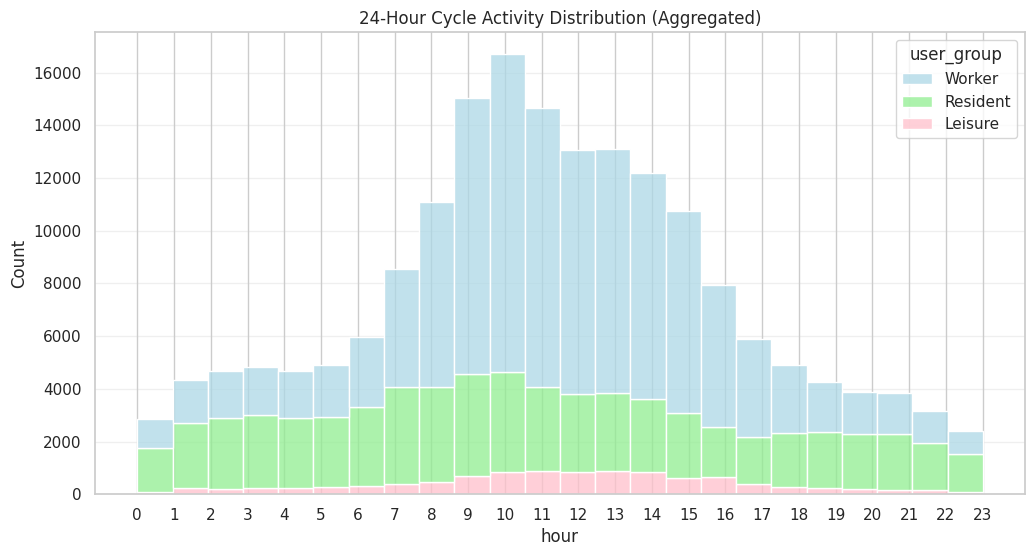

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 加载数据
file_path = "visitations_24h_cycle.csv"
print(f"读取文件: {file_path}")
df = pd.read_csv(file_path)

# 打印列名以防万一
print("当前文件列名:", df.columns.tolist())

# 2. 修复时间列并提取小时
# 注意：这里使用的是 cycle_timestamp
df['cycle_timestamp'] = pd.to_datetime(df['cycle_timestamp'])
df['hour'] = df['cycle_timestamp'].dt.hour

# --- Debug 1: 不同群体的数量对比 ---
print("\n📊 1. 不同群体的原始点数统计:")
counts = df['user_group'].value_counts()
print(counts)
print("-" * 30)

# --- Debug 2: 检查休闲群体 (Leisure) 在办公室 (Office) 的渗透率 ---
# 假设 f_class 是你的功能列名
if 'f_class' in df.columns:
    print("\n📊 2. 跨界行为分析 (Group vs Building Type):")
    cross_tab = pd.crosstab(df['f_class'], df['user_group'])
    print(cross_tab)

    # 计算 Leisure 出现在 Office 的比例
    if 'Office/HQ' in cross_tab.index and 'Leisure' in cross_tab.columns:
        leisure_in_office = cross_tab.loc['Office/HQ', 'Leisure']
        total_leisure = counts['Leisure']
        print(f"\n⚠️ 警告: 有 {leisure_in_office} 个 Leisure 点出现在了 Office 大楼内 (占比 {leisure_in_office/total_leisure:.1%})")

# --- Debug 3: 绘制 24 小时流量曲线 (解决 0 点满盘问题) ---
print("\n📊 3. 正在生成 24 小时活跃分布图...")
plt.figure(figsize=(12, 6))
# 绘制每小时的点数，按群体区分
sns.histplot(data=df, x='hour', hue='user_group', multiple="stack", bins=24,
             palette={'Worker': 'lightblue', 'Resident': 'lightgreen', 'Leisure': 'pink'})

plt.title("24-Hour Cycle Activity Distribution (Aggregated)")
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.3)
plt.show()